In [ ]:
from google.colab import drive
import os
import gc

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define paths
zip_path = '/content/drive/MyDrive/enron_maildir.zip'
extract_path = '/content/enron_data/'

# 3. Unzip silently (-q) to Colab's fast local storage
print("Extracting Enron dataset to local Colab storage... This will take a moment.")
!unzip -q "{zip_path}" -d "{extract_path}"
print("Extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting Enron dataset to local Colab storage... This will take a moment.
Extraction complete!


In [ ]:
import pandas as pd
import email
from email.policy import default

# The path where we just extracted the data
ROOT_DIR = '/content/enron_data/maildir'
email_list = []

print("Parsing emails...")

# Traverse directories
for directory, subdirectory, filenames in os.walk(ROOT_DIR):
    for filename in filenames:
        file_path = os.path.join(directory, filename)
        try:
            with open(file_path, 'r', encoding='latin-1') as f:
                raw_message = f.read()

            parsed_email = email.message_from_string(raw_message, policy=default)

            if parsed_email.is_multipart():
                for part in parsed_email.walk():
                    if part.get_content_type() == "text/plain":
                        body = part.get_payload(decode=True).decode('latin-1', errors='ignore')
                        break
            else:
                body = parsed_email.get_payload(decode=True).decode('latin-1', errors='ignore')

            if body and body.strip():
                email_list.append({'body': body.strip()})

        except Exception:
            continue

df_emails = pd.DataFrame(email_list)
df_emails.drop_duplicates(inplace=True) # Remove duplicate forwarded chains
df_emails.dropna(inplace=True)

print(f"Successfully parsed {len(df_emails)} unique emails.")

Parsing emails...
Successfully parsed 247876 unique emails.


In [ ]:
import re

print("Extracting URLs and cleaning email text...")

# 1. Regex pattern for URLs
url_pattern = r'(https?://\S+|www\.\S+)'

# 2. Extract URLs into a separate list for your Layer 1 URL component
extracted_urls = df_emails['body'].apply(lambda x: re.findall(url_pattern, x))
all_urls = [url for sublist in extracted_urls for url in sublist]
print(f"Extracted {len(all_urls)} URLs for the URL Anomaly Pipeline.")

# Optional: Save URLs to pass to your URL Autoencoder later
# pd.DataFrame(all_urls, columns=['url']).to_csv('/content/drive/MyDrive/Major project/enron_urls.csv', index=False)

# 3. Remove the URLs from the text so the NLP model focuses strictly on language
df_emails['clean_body'] = df_emails['body'].apply(lambda x: re.sub(url_pattern, '', x))

# 4. Basic NLP cleaning (lowercase, remove excess whitespace/newlines)
df_emails['clean_body'] = df_emails['clean_body'].str.lower()
df_emails['clean_body'] = df_emails['clean_body'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Drop rows that became empty after cleaning
df_emails.replace('', pd.NA, inplace=True)
df_emails.dropna(subset=['clean_body'], inplace=True)

print("Text cleaning complete.")

Extracting URLs and cleaning email text...
Extracted 245531 URLs for the URL Anomaly Pipeline.
Text cleaning complete.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

print("Fitting TF-IDF Vectorizer...")

# 1. Initialize TF-IDF (500 features to balance detail and RAM)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')

# 2. Transform the text
X_nlp = tfidf.fit_transform(df_emails['clean_body']).toarray()

# 3. Downcast to float32 to save massive amounts of memory
X_nlp = X_nlp.astype('float32')

# 4. Split into Train/Validation sets
X_train_nlp, X_val_nlp = train_test_split(X_nlp, test_size=0.2, random_state=42)

# Free up RAM by deleting the text dataframes
del df_emails
gc.collect()

print(f"TF-IDF Training Matrix Shape: {X_train_nlp.shape}")

Fitting TF-IDF Vectorizer...
TF-IDF Training Matrix Shape: (197819, 500)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

input_dim = X_train_nlp.shape[1]

# 1. Build the NLP Autoencoder Architecture
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(encoder_input)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
latent_representation = layers.Dense(32, activation='relu')(x) # 32-dim bottleneck

x = layers.Dense(64, activation='relu')(latent_representation)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x)

nlp_autoencoder = models.Model(inputs=encoder_input, outputs=decoder_output)
nlp_autoencoder.compile(optimizer='adam', loss='mse')

# 2. Set up efficient memory pipeline
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_nlp, X_train_nlp)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_nlp, X_val_nlp)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 3. Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/enron_nlp_autoencoder.keras',
    monitor='val_loss',
    save_best_only=True
)

# 4. Train the Model
print("Starting NLP Autoencoder training...")
history = nlp_autoencoder.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)
print("Training complete and model saved to Drive!")

Starting NLP Autoencoder training...
Epoch 1/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 2/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 3/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 4/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 5/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
77

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import paired_cosine_distances

print("Evaluating NLP Autoencoder on Validation Emails...")

# 1. Generate reconstructions on unseen validation emails
reconstructions_nlp = nlp_autoencoder.predict(X_val_nlp, batch_size=256)

# 2. Metric 1: Mean Squared Error (MSE) per email
mse_nlp = np.mean(np.power(X_val_nlp - reconstructions_nlp, 2), axis=1)

# 3. Metric 2: Cosine Similarity between original and reconstructed vectors
# paired_cosine_distances returns (1 - cosine_similarity), so we subtract from 1
cosine_sim_nlp = 1 - paired_cosine_distances(X_val_nlp, reconstructions_nlp)

# 4. Establish 95th / 99th percentile thresholds
threshold_95 = np.percentile(mse_nlp, 95)
threshold_99 = np.percentile(mse_nlp, 99)

print("\n--- NLP Autoencoder Baseline Metrics ---")
print(f"Average Validation MSE: {np.mean(mse_nlp):.6f}")
print(f"Average Cosine Similarity: {np.mean(cosine_sim_nlp):.4f}")
print(f"95th Percentile Threshold: {threshold_95:.6f}")
print(f"99th Percentile Threshold: {threshold_99:.6f}")

Evaluating NLP Autoencoder on Validation Emails...
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

--- NLP Autoencoder Baseline Metrics ---
Average Validation MSE: 0.001133
Average Cosine Similarity: 0.6299
95th Percentile Threshold: 0.001798
99th Percentile Threshold: 0.001969


In [ ]:
# Define test samples: Standard corporate text vs. Suspicious phishing language
test_emails = [
    # Benign Corporate Samples (Enron style)
    "Please find attached the updated schedule for tomorrow's meeting regarding the quarterly report.",
    "Thanks for sending over the contract details. I will review them with the legal team shortly.",

    # Anomaly / Phishing Attack Samples (Zero-day / High-urgency)
    "URGENT: Your account security has been compromised. Verify your bank password immediately or account will be suspended!",
    "Congratulations! You won a lottery prize. Click link to claim your reward before expiry."
]

# 1. Transform test text using the saved TF-IDF vectorizer
X_test_tfidf = tfidf.transform(test_emails).toarray().astype('float32')

# 2. Predict reconstructions
reconstructions_test = nlp_autoencoder.predict(X_test_tfidf)

# 3. Compute MSE for each sample
test_mse = np.mean(np.power(X_test_tfidf - reconstructions_test, 2), axis=1)

# 4. Display Results
print("\n--- Verification Experiment Results ---")
for i, email_text in enumerate(test_emails):
    is_anomaly = test_mse[i] > threshold_99
    status = "🚨 ANOMALY FLAGGED" if is_anomaly else "✅ BENIGN PASS"
    print(f"\nSample [{i+1}]: \"{email_text}\"")
    print(f"Reconstruction MSE: {test_mse[i]:.6f} | Threshold (99th): {threshold_99:.6f}")
    print(f"Status: {status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

--- Verification Experiment Results ---

Sample [1]: "Please find attached the updated schedule for tomorrow's meeting regarding the quarterly report."
Reconstruction MSE: 0.001274 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS

Sample [2]: "Thanks for sending over the contract details. I will review them with the legal team shortly."
Reconstruction MSE: 0.001461 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS

Sample [3]: "URGENT: Your account security has been compromised. Verify your bank password immediately or account will be suspended!"
Reconstruction MSE: 0.001979 | Threshold (99th): 0.001969
Status: 🚨 ANOMALY FLAGGED

Sample [4]: "Congratulations! You won a lottery prize. Click link to claim your reward before expiry."
Reconstruction MSE: 0.000739 | Threshold (99th): 0.001969
Status: ✅ BENIGN PASS


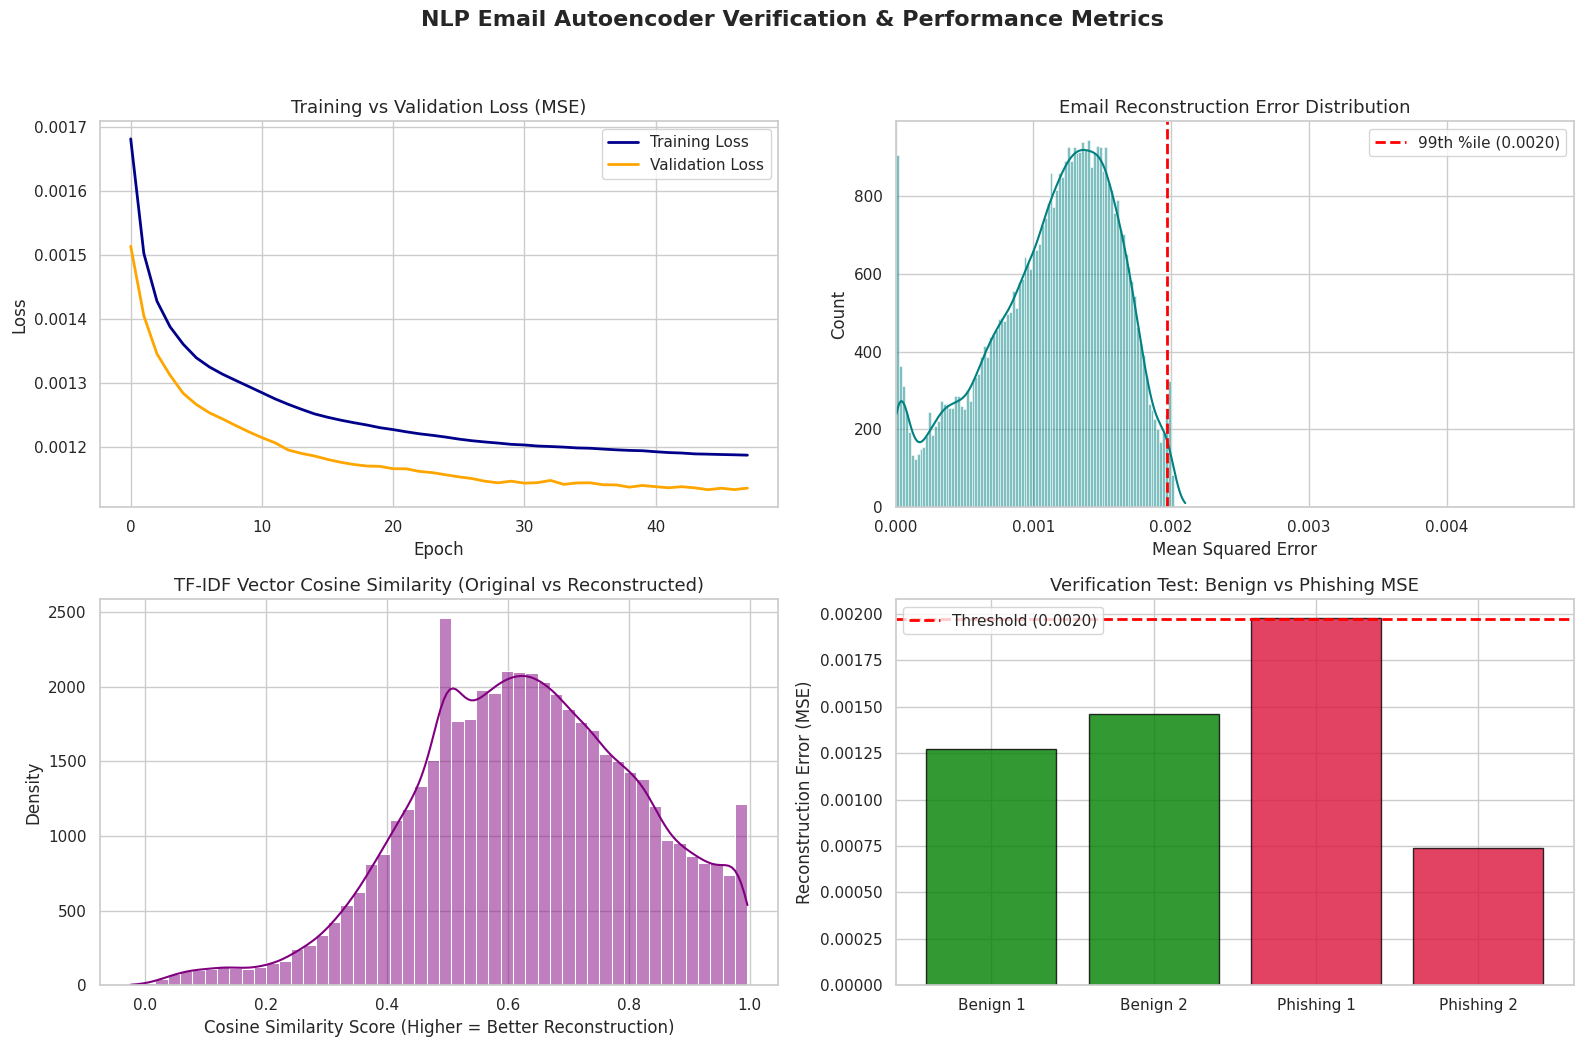

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('NLP Email Autoencoder Verification & Performance Metrics', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# 1. Model Convergence (Loss Curve)
# ---------------------------------------------------------
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='darkblue')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0, 0].set_title('Training vs Validation Loss (MSE)', fontsize=13)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# ---------------------------------------------------------
# 2. Reconstruction Error Distribution & Threshold
# ---------------------------------------------------------
sns.histplot(x=mse_nlp, bins=100, ax=axes[0, 1], color="teal", kde=True)
axes[0, 1].axvline(threshold_99, color='red', linestyle='--', linewidth=2, label=f'99th %ile ({threshold_99:.4f})')
axes[0, 1].set_title('Email Reconstruction Error Distribution', fontsize=13)
axes[0, 1].set_xlabel('Mean Squared Error')
axes[0, 1].set_xlim(0, threshold_99 * 2.5)
axes[0, 1].legend()

# ---------------------------------------------------------
# 3. Cosine Similarity Distribution
# ---------------------------------------------------------
sns.histplot(x=cosine_sim_nlp, bins=50, ax=axes[1, 0], color="purple", kde=True)
axes[1, 0].set_title('TF-IDF Vector Cosine Similarity (Original vs Reconstructed)', fontsize=13)
axes[1, 0].set_xlabel('Cosine Similarity Score (Higher = Better Reconstruction)')
axes[1, 0].set_ylabel('Density')

# ---------------------------------------------------------
# 4. Live Experiment: Benign vs Anomaly Error Comparison
# ---------------------------------------------------------
labels = ['Benign 1', 'Benign 2', 'Phishing 1', 'Phishing 2']
colors = ['green', 'green', 'crimson', 'crimson']

axes[1, 1].bar(labels, test_mse, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].axhline(threshold_99, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold_99:.4f})')
axes[1, 1].set_title('Verification Test: Benign vs Phishing MSE', fontsize=13)
axes[1, 1].set_ylabel('Reconstruction Error (MSE)')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()